# MSCS 634 Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms

**Name:** Bikram Lamsal  
**Course Title:** MSCS 634 - Advanced Big Data and Data Mining  
**Lab Assignment Title:** Lab 3 - Clustering Analysis Using K-Means and K-Medoids Algorithms

## Step 1: Load and Prepare the Dataset

This section loads the Wine dataset from `sklearn`, reviews the feature columns and class distribution, and standardizes the data using z-score normalization. Standardization is important because K-Means and K-Medoids both rely on distance calculations, and the Wine features are measured on different numeric scales.

In [1]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, pairwise_distances, silhouette_score
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")

wine_df = X.copy()
wine_df["target"] = y
wine_df["class_name"] = y.map(dict(enumerate(wine.target_names)))

print(f"Dataset shape: {X.shape[0]} rows and {X.shape[1]} features")
print("Target classes:", list(wine.target_names))
wine_df.head()

Dataset shape: 178 rows and 13 features
Target classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [3]:
feature_summary = X.describe().T[["mean", "std", "min", "max"]]
feature_summary

,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00


In [4]:
class_distribution = (
    wine_df["class_name"]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="count")
)
class_distribution

,class_name,count
0,class_1,71
1,class_0,59
2,class_2,48


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_summary = pd.DataFrame(X_scaled, columns=wine.feature_names).describe().T[["mean", "std", "min", "max"]]
scaled_summary

,mean,std,min,max
alcohol,7.943708e-15,1.002821,-2.434235,2.259772
malic_acid,3.592632e-16,1.002821,-1.432983,3.109192
ash,-4.066660e-15,1.002821,-3.679162,3.156325
alcalinity_of_ash,-7.983626e-17,1.002821,-2.671018,3.154511
magnesium,-7.983626e-17,1.002821,-2.088255,4.371372
total_phenols,-3.991813e-17,1.002821,-2.107246,2.539515
flavanoids,9.979533e-16,1.002821,-1.695971,3.062832
nonflavanoid_phenols,-5.588538e-16,1.002821,-1.868234,2.402403
proanthocyanins,-1.656602e-15,1.002821,-2.069034,3.485073
color_intensity,-3.442939e-16,1.002821,-1.634288,3.435432


### Dataset Preparation Interpretation

The dataset contains 178 wine records, 13 numeric chemical-property features, and 3 known wine classes. The original feature summary shows large scale differences, especially between variables such as `proline` and smaller-range variables such as `hue`. Z-score normalization centers each feature near 0 and scales it to a comparable standard deviation, preventing large-scale variables from dominating the clustering distance calculations.

## Step 2: Implement K-Means Clustering

K-Means is implemented with `k=3` because the Wine dataset has three known classes. The model assigns each observation to the nearest cluster centroid. Clustering quality is evaluated with Silhouette Score and Adjusted Rand Index (ARI).

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

kmeans_metrics = pd.DataFrame([
    {
        "algorithm": "K-Means",
        "silhouette_score": kmeans_silhouette,
        "adjusted_rand_index": kmeans_ari,
    }
])
kmeans_metrics

,algorithm,silhouette_score,adjusted_rand_index
0,K-Means,0.284859,0.897495


### K-Means Interpretation

K-Means produced a moderate Silhouette Score and a high ARI. The high ARI means the K-Means cluster assignments closely matched the actual wine classes, even though the true labels were not used during training. This indicates that the standardized chemical features contain strong natural grouping structure that K-Means can capture with centroid-based clusters.

## Step 3: Implement K-Medoids Clustering

K-Medoids is also implemented with `k=3`. Unlike K-Means, each cluster center is an actual data point called a medoid. Since K-Medoids is not included in core `sklearn`, this notebook uses a compact Partitioning Around Medoids (PAM-style) implementation based on pairwise distances.

In [7]:
def initialize_medoids(X_values, n_clusters, random_state=42):
    """Choose deterministic initial medoids from random unique observations."""
    rng = np.random.default_rng(random_state)
    return rng.choice(X_values.shape[0], size=n_clusters, replace=False)


def fit_kmedoids(X_values, n_clusters=3, max_iter=100, random_state=42):
    """Fit a simple PAM-style K-Medoids model and return medoid indices and labels."""
    distances = pairwise_distances(X_values, metric="euclidean")
    medoid_indices = initialize_medoids(X_values, n_clusters, random_state=random_state)

    for _ in range(max_iter):
        labels = np.argmin(distances[:, medoid_indices], axis=1)
        updated_medoids = medoid_indices.copy()

        for cluster_id in range(n_clusters):
            cluster_indices = np.where(labels == cluster_id)[0]
            if len(cluster_indices) == 0:
                continue

            cluster_distances = distances[np.ix_(cluster_indices, cluster_indices)]
            updated_medoids[cluster_id] = cluster_indices[np.argmin(cluster_distances.sum(axis=1))]

        if np.array_equal(updated_medoids, medoid_indices):
            break

        medoid_indices = updated_medoids

    labels = np.argmin(distances[:, medoid_indices], axis=1)
    return medoid_indices, labels


kmedoids_medoid_indices, kmedoids_labels = fit_kmedoids(
    X_scaled,
    n_clusters=3,
    random_state=42
)

kmedoids_silhouette = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

kmedoids_metrics = pd.DataFrame([
    {
        "algorithm": "K-Medoids",
        "silhouette_score": kmedoids_silhouette,
        "adjusted_rand_index": kmedoids_ari,
    }
])

print("Medoid row indices:", kmedoids_medoid_indices)
kmedoids_metrics

Medoid row indices: [106  35 148]


,algorithm,silhouette_score,adjusted_rand_index
0,K-Medoids,0.267622,0.741137


### K-Medoids Interpretation

K-Medoids produced a lower Silhouette Score and ARI than K-Means in this experiment. Because medoids must be actual observations, the resulting cluster centers can be more robust to outliers but may be less flexible than K-Means centroids. In this Wine dataset, the centroid-based approach better matched the natural class structure after standardization.

## Step 4: Visualize and Compare Results

PCA is used to reduce the standardized 13-feature dataset to two components for visualization. The clustering algorithms are still evaluated on the full standardized feature set, while the PCA projection is used only to make the cluster positions visible in two dimensions.

### Actual Class Reference Plot

Before comparing the clustering outputs, the standardized data is projected into two PCA components and colored by the known wine classes. This reference plot is not used to train the clustering models; it helps visually compare whether the unsupervised clusters resemble the actual class structure.

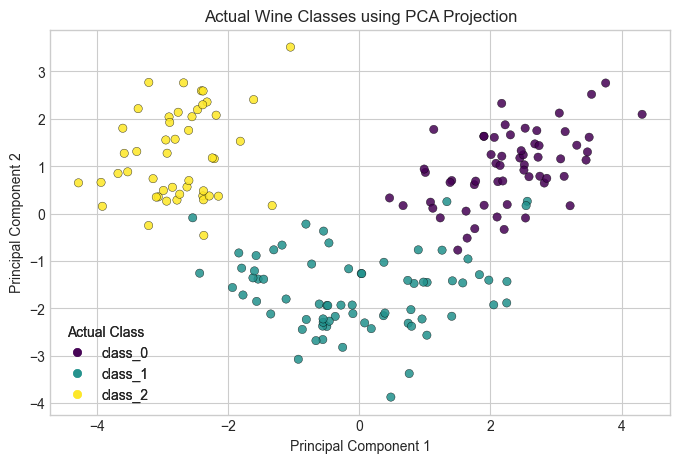

In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k",
    linewidth=0.3,
    alpha=0.85
)
ax.set_title("Actual Wine Classes using PCA Projection")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
legend = ax.legend(
    handles=scatter.legend_elements()[0],
    labels=list(wine.target_names),
    title="Actual Class"
)
ax.add_artist(legend)
plt.show()

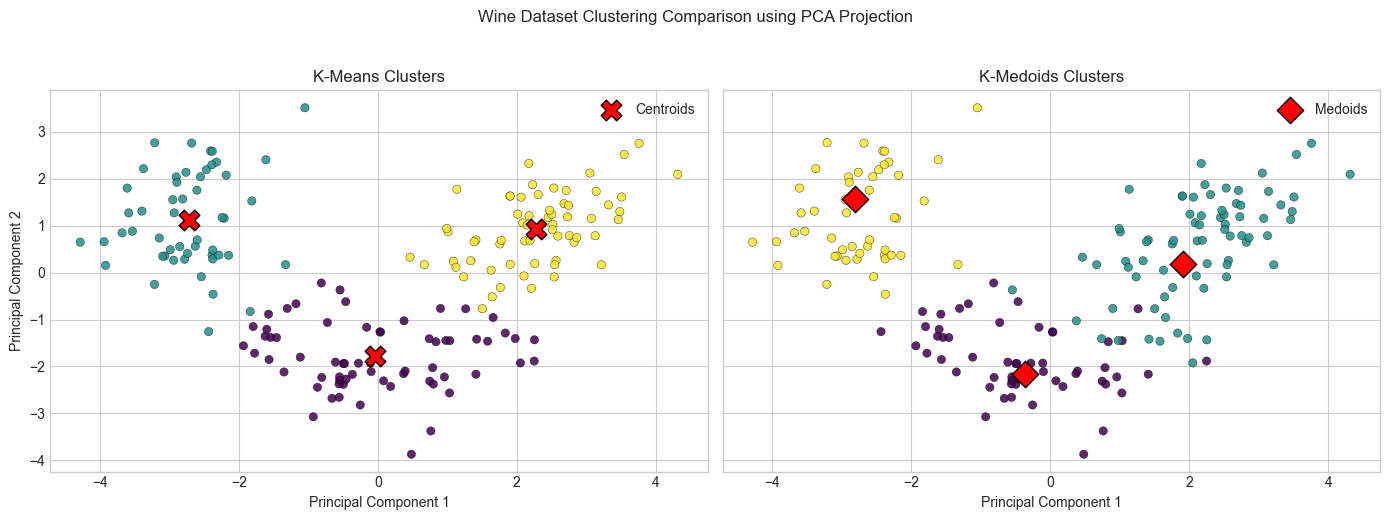

In [9]:
kmeans_centers_pca = pca.transform(kmeans.cluster_centers_)
kmedoids_medoids_pca = X_pca[kmedoids_medoid_indices]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

scatter_1 = axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    edgecolor="k",
    linewidth=0.3,
    alpha=0.85
)
axes[0].scatter(
    kmeans_centers_pca[:, 0],
    kmeans_centers_pca[:, 1],
    c="red",
    marker="X",
    s=220,
    edgecolor="black",
    label="Centroids"
)
axes[0].set_title("K-Means Clusters")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend()

scatter_2 = axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmedoids_labels,
    cmap="viridis",
    edgecolor="k",
    linewidth=0.3,
    alpha=0.85
)
axes[1].scatter(
    kmedoids_medoids_pca[:, 0],
    kmedoids_medoids_pca[:, 1],
    c="red",
    marker="D",
    s=180,
    edgecolor="black",
    label="Medoids"
)
axes[1].set_title("K-Medoids Clusters")
axes[1].set_xlabel("Principal Component 1")
axes[1].legend()

fig.suptitle("Wine Dataset Clustering Comparison using PCA Projection", y=1.03)
plt.tight_layout()
plt.show()

In [10]:
comparison = pd.concat([kmeans_metrics, kmedoids_metrics], ignore_index=True)
comparison

,algorithm,silhouette_score,adjusted_rand_index
0,K-Means,0.284859,0.897495
1,K-Medoids,0.267622,0.741137


### Metric Comparison Plot

The table gives exact metric values, while the bar chart makes the performance gap easier to compare. Higher values are better for both Silhouette Score and ARI.

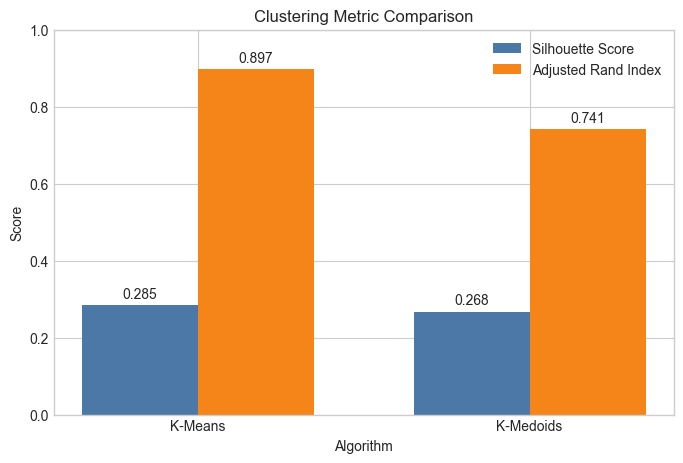

In [11]:
metrics_long = comparison.melt(
    id_vars="algorithm",
    value_vars=["silhouette_score", "adjusted_rand_index"],
    var_name="metric",
    value_name="score"
)

fig, ax = plt.subplots(figsize=(8, 5))
bar_width = 0.35
algorithms = comparison["algorithm"].tolist()
x = np.arange(len(algorithms))

silhouette_values = comparison["silhouette_score"].to_numpy()
ari_values = comparison["adjusted_rand_index"].to_numpy()

ax.bar(x - bar_width / 2, silhouette_values, width=bar_width, label="Silhouette Score", color="#4C78A8")
ax.bar(x + bar_width / 2, ari_values, width=bar_width, label="Adjusted Rand Index", color="#F58518")

ax.set_title("Clustering Metric Comparison")
ax.set_xlabel("Algorithm")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(algorithms)
ax.set_ylim(0, 1)
ax.legend()

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.show()

### Metric Interpretation

The metric comparison confirms that K-Means outperformed K-Medoids on both measures. The difference in Silhouette Score is small, so both methods found some visible structure in the standardized feature space. The ARI difference is larger, which means K-Means aligned much more closely with the actual class labels than K-Medoids did.

In [12]:
kmeans_crosstab = pd.crosstab(
    y.map(dict(enumerate(wine.target_names))),
    kmeans_labels,
    rownames=["actual_class"],
    colnames=["kmeans_cluster"]
)

kmedoids_crosstab = pd.crosstab(
    y.map(dict(enumerate(wine.target_names))),
    kmedoids_labels,
    rownames=["actual_class"],
    colnames=["kmedoids_cluster"]
)

print("K-Means clusters vs. actual classes")
display(kmeans_crosstab)

print("K-Medoids clusters vs. actual classes")
display(kmedoids_crosstab)

K-Means clusters vs. actual classes


kmeans_cluster,0,1,2
actual_class,,,
class_0,0,0,59
class_1,65,3,3
class_2,0,48,0


K-Medoids clusters vs. actual classes


kmedoids_cluster,0,1,2
actual_class,,,
class_0,0,59,0
class_1,55,15,1
class_2,0,0,48


### Comparison Interpretation

K-Means produced better-defined clusters based on both evaluation metrics. Its Silhouette Score was higher, showing stronger separation and cohesion, and its ARI was substantially higher, showing closer agreement with the actual Wine class labels. In the PCA visualization, K-Means forms more compact groups around centroids, while K-Medoids creates clusters around actual representative observations and shows more overlap between two of the wine groups.

K-Means may be preferable when clusters are roughly compact and spherical and when the mean location is a useful representative center. K-Medoids may be preferable when the dataset contains outliers or when it is important for each cluster center to be an actual observed data point. For this standardized Wine dataset, K-Means was the stronger method.

The actual-class reference plot provides useful context: the Wine classes are partly separable in the first two principal components, but there is still overlap. That overlap explains why the Silhouette Scores are moderate rather than very high, even though K-Means achieves a strong ARI.